# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [1]:
# Enter your course email here
student_email = "rakibulhassanratulkhan84@gmail.com"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:**

Sigmoid vs ReLU

Sigmoid converts the input into a value between 0 and 1. It is smooth and useful for binary classification output layers.

ReLU outputs 0 for negative inputs and keeps positive inputs unchanged. It is simple and computationally fast.

Why ReLU is preferred in hidden layers:
ReLU helps deep networks learn faster and reduces the vanishing gradient problem. It also makes the network more efficient because many negative activations become zero.

Problem with Sigmoid in deep networks:
Sigmoid can cause the vanishing gradient problem during backpropagation. Its gradients become very small, especially for very large or very small inputs. As a result, earlier layers learn very slowly, making deep networks difficult to train.




**Part B Answer:**

Gradient Descent Types

1. Batch Gradient Descent
Uses all training data to calculate the gradient before updating the model.

Advantage: Stable and accurate updates.
Disadvantage: Slow and requires more memory for large datasets.

2. Stochastic Gradient Descent (SGD)
Uses one training sample at a time to update the model.

Advantage: Faster updates and uses less memory.
Disadvantage: Updates are noisy and the training path can be unstable.

3. Mini-batch Gradient Descent
Uses a small group of samples (such as 32 or 64) for each update.

Advantage: Provides a good balance between speed, stability, and memory usage.
Disadvantage: Requires choosing an appropriate batch size.
Recommendation for Fashion-MNIST

Mini-batch Gradient Descent is recommended because Fashion-MNIST has 60,000 images. It is more memory-efficient than Batch Gradient Descent and more stable than pure SGD, while also working efficiently with GPUs.

**Part C Answer:**

1. Why use nn.CrossEntropyLoss instead of nn.BCELoss?

Fashion-MNIST has 10 mutually exclusive classes, where each image belongs to only one class. nn.CrossEntropyLoss is designed for multi-class classification. nn.BCELoss is mainly used for binary or multi-label classification.

2. Why not use nn.Softmax before nn.CrossEntropyLoss?

nn.CrossEntropyLoss already applies Softmax internally. Adding another Softmax is unnecessary and can make training less stable.

3. What does loss.backward() do?

loss.backward() performs backpropagation. It calculates the gradients of the loss with respect to the model's parameters. These gradients are then used by the optimizer to update the weights and improve the model.



---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.9MB/s]

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

<function matplotlib.pyplot.show(close=None, block=None)>

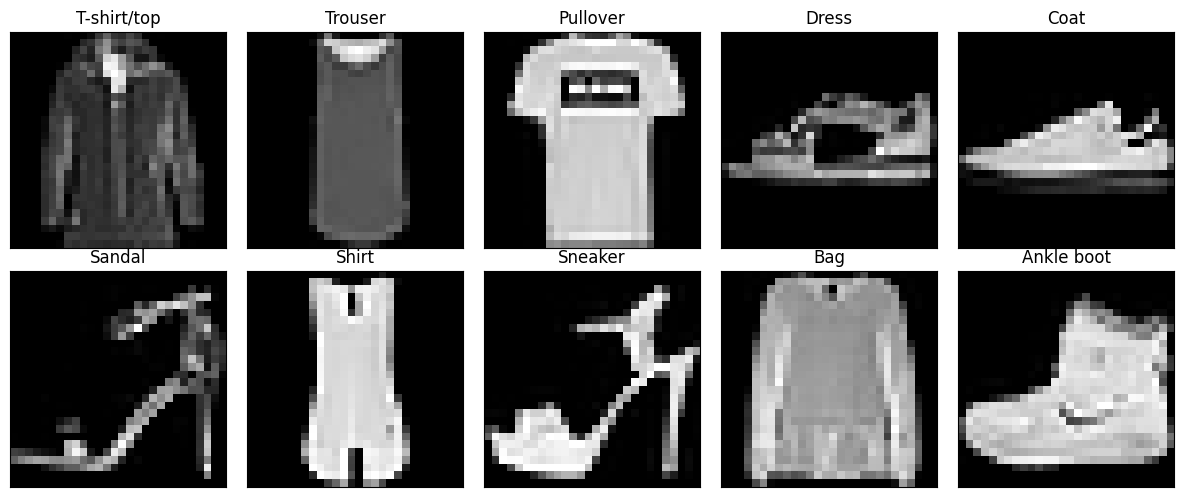

In [3]:
fig,axes=plt.subplots(2,5,figsize=(12,5))

for class_id, ax in enumerate(axes.flat):
  idx=np.where(test_labels_all==class_id)[0][0]
  ax.imshow(train_images_all[idx],cmap='gray')
  ax.set_title(class_names[class_id])
  ax.set_xticks([])
  ax.set_yticks([])
plt.tight_layout()
plt.show


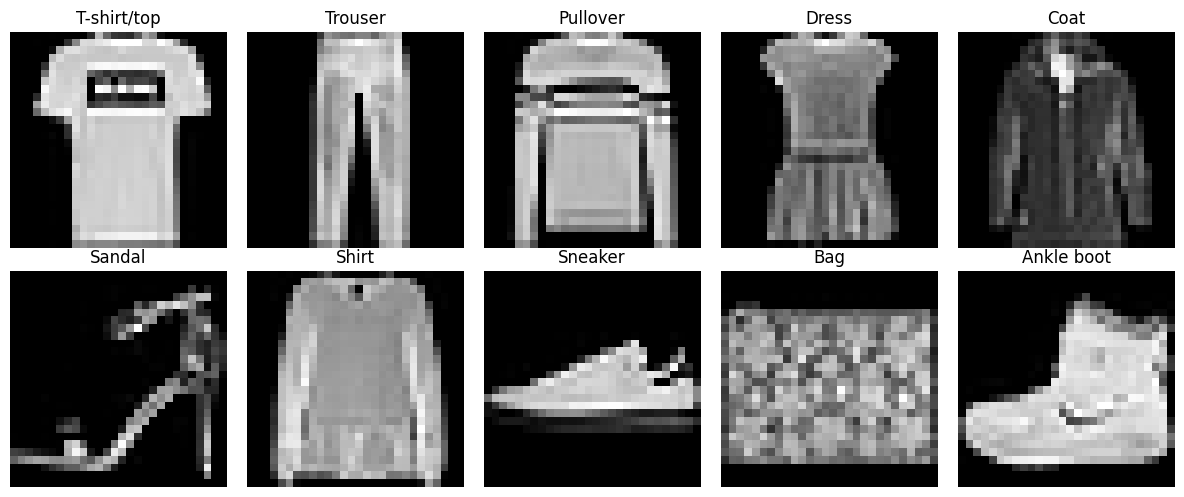

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

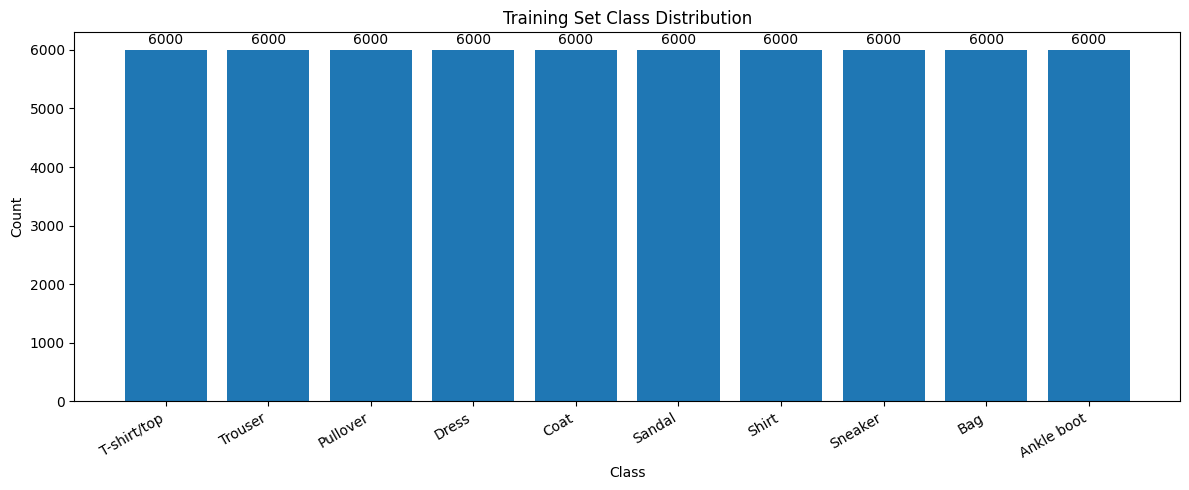

In [4]:
class_counts = np.bincount(train_labels_all, minlength=10)
plt.figure(figsize=(12,5))
bars=plt.bar(class_names,class_counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Set Class Distribution")
plt.xticks(rotation=30,ha="right")

for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()


### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [10]:
from re import X
from sklearn.model_selection import train_test_split

X_all=train_images_all.astype(np.float32) /255.0
X_test_np=test_images_all.astype(np.float32) /255.0

X_train_np,X_val_np,y_train_np,y_val_np=train_test_split(
    X_all,
    train_labels_all,
    test_size=10000,
    random_state=42
)
X_train=torch.tensor(X_train_np,dtype=torch.float32)
X_val=torch.tensor(X_val_np,dtype=torch.float32)
X_test=torch.tensor(X_test_np,dtype=torch.float32)


y_train=torch.tensor(y_train_np,dtype=torch.long)
y_val=torch.tensor(y_val_np,dtype=torch.long)
y_test=torch.tensor(test_labels_all,dtype=torch.long)




In [11]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [13]:
batch_size=64

train_dataset=TensorDataset(X_train,y_train)
val_dataset=TensorDataset(X_val,y_val)
test_dataset=TensorDataset(X_test,y_test)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=True)



In [14]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [15]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

model = FashionClassifier()
print(model)


FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [16]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [17]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)
epochs=15


### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [18]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = running_loss / total
    train_accuracy = 100.0 * correct / total


    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_running_loss += loss.item() * batch_X.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == batch_y).sum().item()
            val_total += batch_y.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = 100.0 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Acc: {val_accuracy:.2f}%"
    )


Epoch 1/15 | Train Loss: 1.9460 | Val Loss: 1.2406 | Train Acc: 30.06% | Val Acc: 56.78%
Epoch 2/15 | Train Loss: 0.9674 | Val Loss: 0.8642 | Train Acc: 63.05% | Val Acc: 66.08%
Epoch 3/15 | Train Loss: 0.7447 | Val Loss: 0.8186 | Train Acc: 72.11% | Val Acc: 68.64%
Epoch 4/15 | Train Loss: 0.6469 | Val Loss: 0.6424 | Train Acc: 76.74% | Val Acc: 77.23%
Epoch 5/15 | Train Loss: 0.5889 | Val Loss: 0.6561 | Train Acc: 78.88% | Val Acc: 78.10%
Epoch 6/15 | Train Loss: 0.5490 | Val Loss: 0.5555 | Train Acc: 80.77% | Val Acc: 80.45%
Epoch 7/15 | Train Loss: 0.5204 | Val Loss: 0.6139 | Train Acc: 81.65% | Val Acc: 79.17%
Epoch 8/15 | Train Loss: 0.4962 | Val Loss: 0.6174 | Train Acc: 82.61% | Val Acc: 77.55%
Epoch 9/15 | Train Loss: 0.4751 | Val Loss: 0.4736 | Train Acc: 83.20% | Val Acc: 83.56%
Epoch 10/15 | Train Loss: 0.4599 | Val Loss: 0.5718 | Train Acc: 83.87% | Val Acc: 80.75%
Epoch 11/15 | Train Loss: 0.4459 | Val Loss: 0.4631 | Train Acc: 84.24% | Val Acc: 83.69%
Epoch 12/15 | Train

In [19]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 85.70%, Final Val Acc: 84.09%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [22]:
model.eval()
all_preds=[]
all_labels=[]
correct=0
total=0

with torch.no_grad():
    for batch_x,batch_y in test_loader:
       outputs=model(batch_x)
       predictions=outputs.argmax(dim=1)

       correct+=(predictions==batch_y).sum().item()
       total+=batch_y.size(0)

       all_preds.extend(predictions.cpu().numpy().tolist())
       all_labels.extend(batch_y.cpu().numpy().tolist())

test_accuracy=100.0*correct/total
print(f"Test accuracy:{test_accuracy:.2f}%")


Test accuracy:83.22%


In [23]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 83.22%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

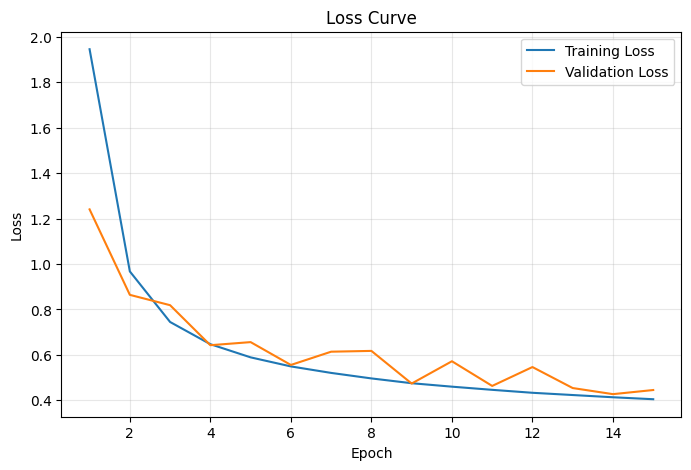

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(1,epochs+1),train_losses,label="Training Loss")
plt.plot(range(1,epochs+1),val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

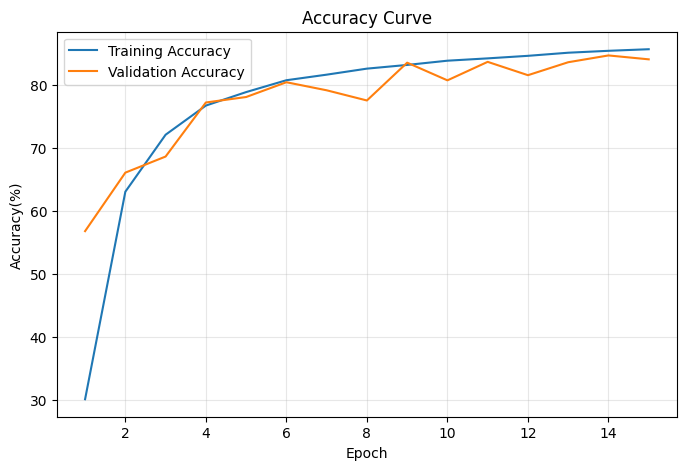

In [25]:
plt.figure(figsize=(8,5))
plt.plot(range(1,epochs+1),train_accuracies,label="Training Accuracy")
plt.plot(range(1,epochs+1),val_accuracies,label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy(%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

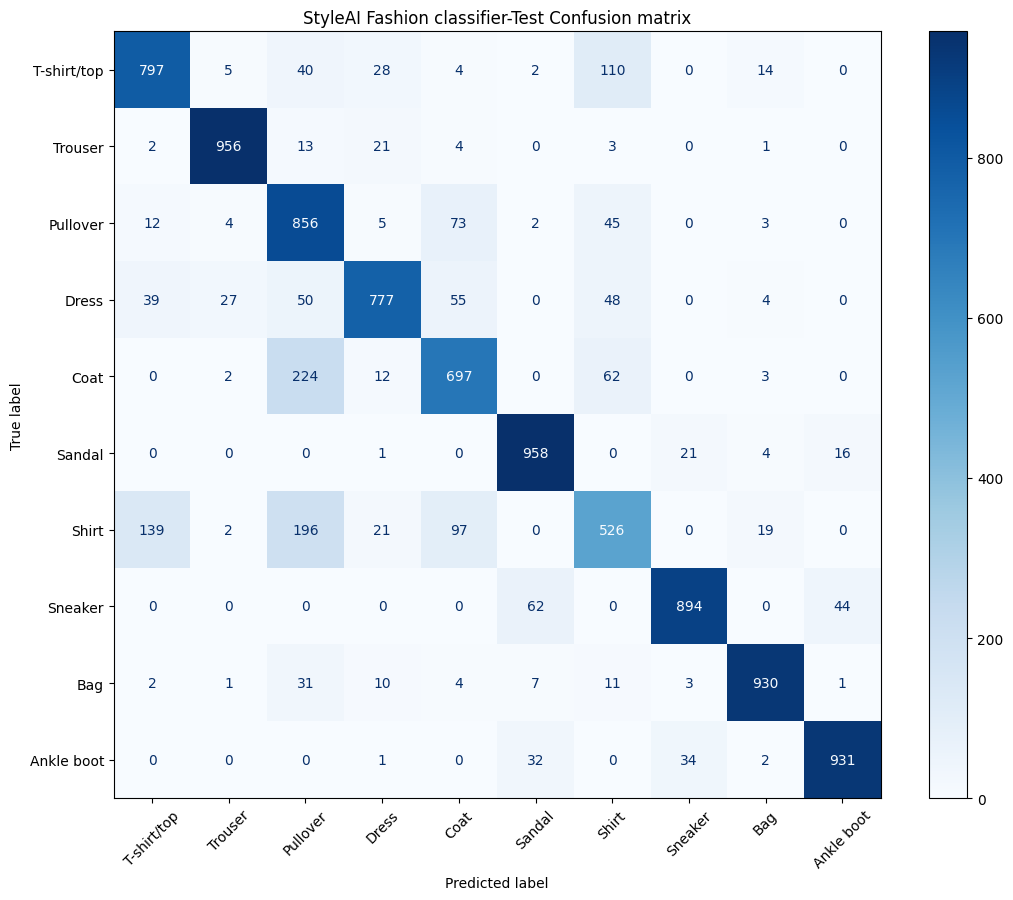

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm=confusion_matrix(all_labels,all_preds)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
fig,ax=plt.subplots(figsize=(11,9))
disp.plot(ax=ax,cmap="Blues",xticks_rotation=45,colorbar=True)
ax.set_title("StyleAI Fashion classifier-Test Confusion matrix")
plt.tight_layout()
plt.show()

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [27]:
from sklearn.metrics import classification_report

print(classification_report( all_labels,all_preds,target_names=class_names))


              precision    recall  f1-score   support

 T-shirt/top       0.80      0.80      0.80      1000
     Trouser       0.96      0.96      0.96      1000
    Pullover       0.61      0.86      0.71      1000
       Dress       0.89      0.78      0.83      1000
        Coat       0.75      0.70      0.72      1000
      Sandal       0.90      0.96      0.93      1000
       Shirt       0.65      0.53      0.58      1000
     Sneaker       0.94      0.89      0.92      1000
         Bag       0.95      0.93      0.94      1000
  Ankle boot       0.94      0.93      0.93      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**My Analysis:**

1.Most confused classes:

Shirt and T-shirt/top are most often confused because their shapes and grayscale patterns look very similar at the low 28×28 pixel resolution.

2.Overfitting or underfitting:

The model shows overfitting if training accuracy keeps increasing while validation accuracy stops improving, and validation loss starts increasing.

